# How to import and export a h5 file

Before you start, you should install all necessary FELiCS packages, and install FELiCS as a package itself. The [installation guide](https://felics-d43476.gitlab.io/installation_guide.html) explains those steps in detail.

After installing FELiCS you can start writing your first FELiCS script. 

Here, we have used gmsh to create a square mesh, which we exported in ASCII format. If you need a more detailed explanation you can have a look [here](https://felics-d43476.gitlab.io/Tutorials/cylinder_wake.html).

**Step 1: Create a FELiCSMesh**

The FELiCSMesh is a wrapper for a dolfinx mesh, that contains additional attributes and methods, e.g. the coordinate system of your case. 

In [1]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName         = "Input/square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName, meshFileName)

fatal: not a git repository: '/home/demange/anaconda3/envs/felics/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 124 ) : Opening mesh file: Input/square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 132 ) : Mesh contains 513 nodes and 1024 elements


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 


**Step 2: Create a scalar function space**

Next we create a dolfinx function space from our FELiCSMesh object with the polynomial degree and the dimension of the space. In FELiCS, only continuous Lagrange elements are used. Because our space should be scalar, we choose dim=1.

In [3]:
from FELiCS.SpaceDisc.FEMSpaces import create_function_space

space = create_function_space(mesh, degree=2, dim=1)

**Step 3: Create fields and import from H5 files**

Now things are getting interesting. The Field object can store fields on our function space, as the name suggests. It contains a dolfinx function, as well as a FELiCS tensor object (which we use to make our expressions coordinatesystem independent). We can import data to our Field from a h5 file, but also export our created data to h5. Fields can be naturally added to eachother using the standard python operators. Make sure, that the fields are defined on the same space, otherwise the sum cannot be computed.

In [5]:
from FELiCS.IO.Reader    import Reader
from FELiCS.IO.Writer    import Writer
from FELiCS.Fields.Field import Field

# create Reader object
reader = Reader()
# for the Writer object, the default export directory is "Output"
writer = Writer()

# create Field object
Field1 = Field(space, mesh=mesh, name="function_sine")
# import data: the name of the field should be the same as the name of the data set to import
Field1.import_data(reader, importFilePath="Input/input") 

Field2 = Field(space, mesh=mesh, name="function_square")
Field2.import_data(reader, importFilePath="Input/input") 


Field3 = Field1 + Field2

Field3.export_to_h5(writer, "field_sum")


Info     | Reader.py              | _interpolate_to_calc_mesh  (line 706 ) : Linear interpolation took 0.1 seconds. (Mesh size: (1969, 2))


**Visualize the results**

The resulting "xmf" file, which has been exported to the default export directory "Output", can be loaded e.g. into Paraview. For small meshes, the plot functionality of "Field" can be used:

<Axes: xlabel='x', ylabel='y'>

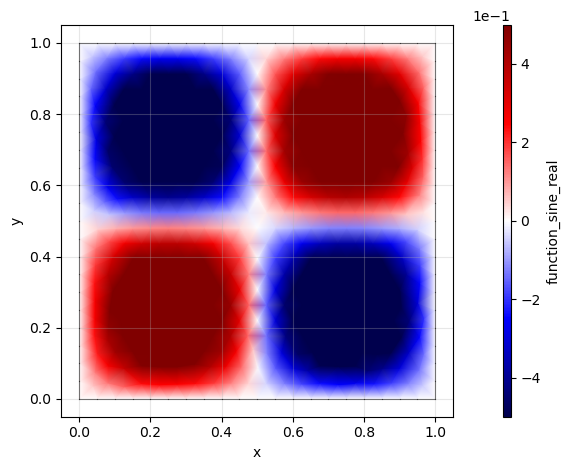

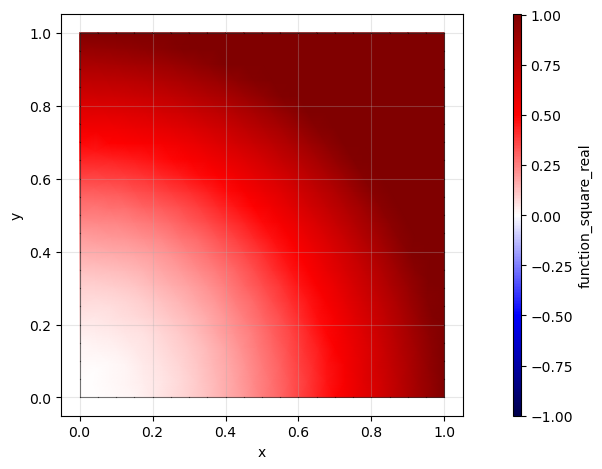

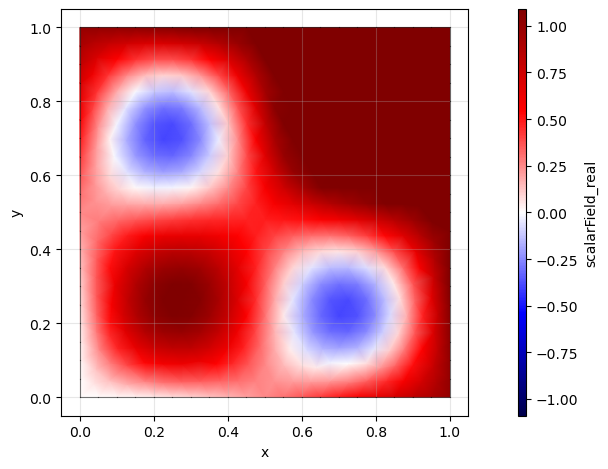

In [6]:
Field1.plot()
Field2.plot()
Field3.plot()